In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [9]:
df = pd.read_parquet("data_for_student.parquet")
print(df.shape)
print(df.dtypes)
print(df.head(3))

(379534, 5)
raw_file                str
scan                  int64
modified_sequence       str
matched_ions         object
intensity            object
dtype: object
                                            raw_file  scan  \
0  EXPLO_NGL_YD1_240712_Expi_LysC_ECD50ms_900kHz_...  3732   
1  EXPLO_NGL_YD1_240712_Expi_LysC_ECD50ms_900kHz_...  3849   
2  EXPLO_NGL_YD1_240712_Expi_LysC_ECD50ms_900kHz_...  3890   

            modified_sequence  \
0     EENRRPPSGDNAREKPPSSGVKK   
1  VRNHYNEEM[UNIMOD:35]SNLRNK   
2            EHQRILARRQTIEERK   

                                        matched_ions  \
0  [C4, z4, z5, C9^2, z9^2, C11^2, z11^2, Z11^2, ...   
1  [C3, z3, C4, z4, Z4, C5, z5, Z5, C6, z6, Z6, C...   
2  [C3, z3, Z3, C4, z4, Z4, C5, z5, Z5, C6, z6, C...   

                                           intensity  
0  [4693.457, 2065.6274, 3287.1636, 7479.8574, 24...  
1  [27414.615, 30732.162, 51714.02, 41634.367, 14...  
2  [18523.092, 17844.998, 4973.6216, 8429.15, 112...  


In [10]:
print(df['modified_sequence'][0])
print(df['matched_ions'][0])
print(df['intensity'][0])

EENRRPPSGDNAREKPPSSGVKK
['C4' 'z4' 'z5' 'C9^2' 'z9^2' 'C11^2' 'z11^2' 'Z11^2' 'C12^2' 'z12^2'
 'z13^2' 'Z13^2' 'C14^2' 'z14^2' 'Z14^2' 'Z15^2' 'Z16^2' 'C19^2' 'Z19^2'
 'C19^3' 'z19^3' 'Z19^3' 'C20^3' 'C21^3']
[4693.457  2065.6274 3287.1636 7479.8574 2479.2307 1722.7812 4399.819
 1359.5806 6374.667  2548.7522 2917.0337 1482.6566 2088.1287 3228.5737
 1847.055  1776.3076 1752.1339 1390.6683 1440.4368 2257.448  2574.9387
 5246.2407 3000.2905 1710.0319]


In [11]:
df['n_ions'] = df['matched_ions'].apply(len)
df['pep_length'] = df['modified_sequence'].apply(len)
df['mean_intensity'] = df['intensity'].apply(np.mean)
print(df['n_ions'].describe())
print(df['pep_length'].describe())

/usr/lib/python3/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


count    379534.000000
mean         23.806289
std          17.127094
min           0.000000
25%          11.000000
50%          18.000000
75%          33.000000
max         125.000000
Name: n_ions, dtype: float64
count    379534.000000
mean         17.420463
std           8.461628
min           7.000000
25%          11.000000
50%          15.000000
75%          22.000000
max          98.000000
Name: pep_length, dtype: float64


In [12]:
all_ions = list(itertools.chain.from_iterable(df['matched_ions']))
ion_types = set(ion[0] for ion in all_ions)
print(ion_types)

charges = set()
for ions in df['matched_ions']:
    for ion in ions:
        if '^' in ion:
            charges.add(ion.split('^')[1])
        else:
            charges.add('1')
print(sorted(charges))

has_mod = df['modified_sequence'].str.contains('\[')
print(f"Modified peptides: {has_mod.sum()} / {len(df)}")

<>:14: SyntaxWarning: invalid escape sequence '\['
<>:14: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_20570/3927135849.py:14: SyntaxWarning: invalid escape sequence '\['
  has_mod = df['modified_sequence'].str.contains('\[')


{'C', 'z', 'Z'}
['1', '2', '3']
Modified peptides: 82631 / 379534


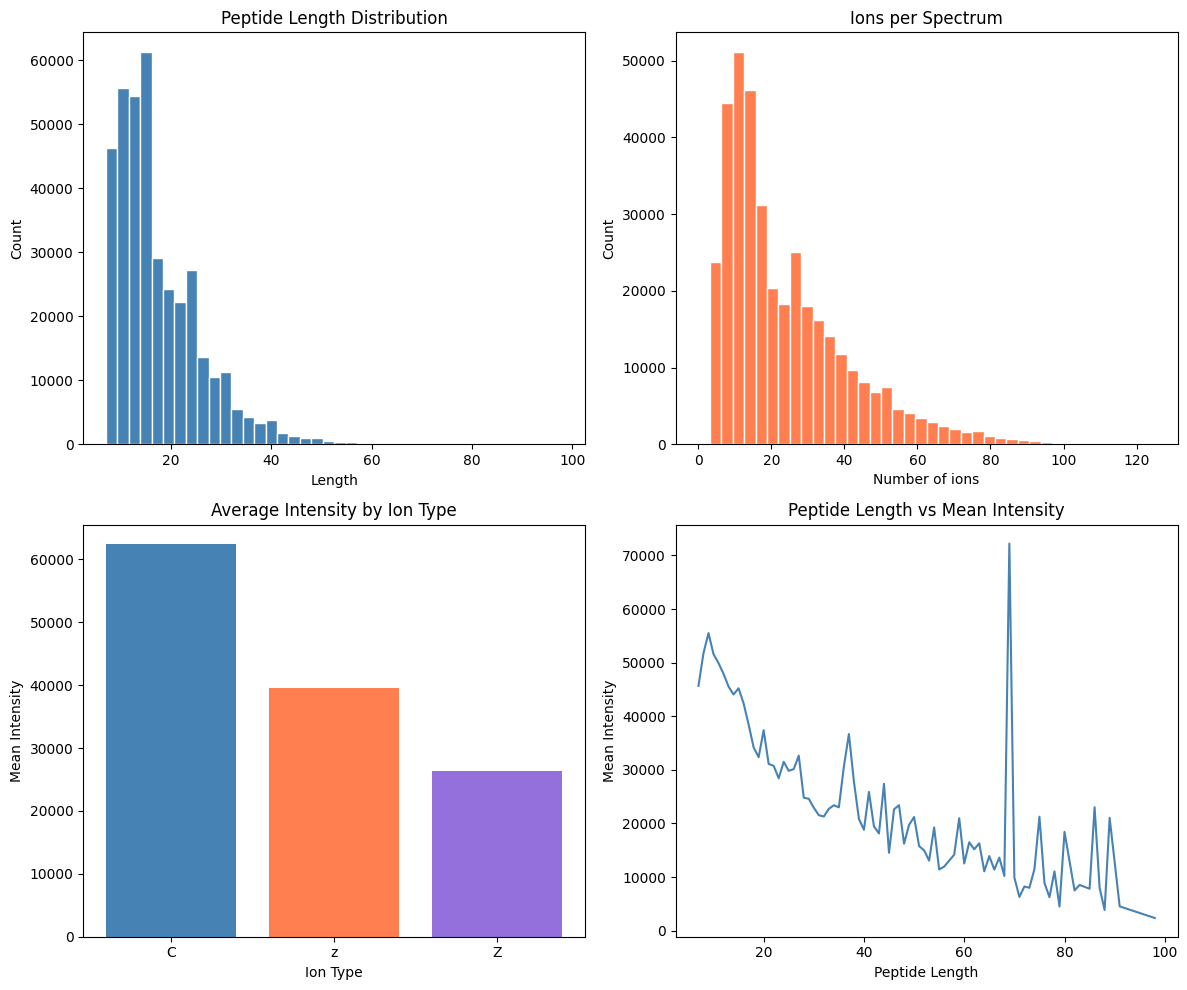

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(df['pep_length'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Peptide Length Distribution')
axes[0,0].set_xlabel('Length')
axes[0,0].set_ylabel('Count')

axes[0,1].hist(df['n_ions'], bins=40, color='coral', edgecolor='white')
axes[0,1].set_title('Ions per Spectrum')
axes[0,1].set_xlabel('Number of ions')
axes[0,1].set_ylabel('Count')

ion_intensities = {'C': [], 'z': [], 'Z': []}
for ions, intensities in zip(df['matched_ions'], df['intensity']):
    for ion, intensity in zip(ions, intensities):
        ion_type = ion[0]
        if ion_type in ion_intensities:
            ion_intensities[ion_type].append(intensity)

means = {k: np.mean(v) for k, v in ion_intensities.items()}
axes[1,0].bar(means.keys(), means.values(), color=['steelblue', 'coral', 'mediumpurple'])
axes[1,0].set_title('Average Intensity by Ion Type')
axes[1,0].set_xlabel('Ion Type')
axes[1,0].set_ylabel('Mean Intensity')

length_groups = df.groupby('pep_length')['mean_intensity'].mean()
axes[1,1].plot(length_groups.index, length_groups.values, color='steelblue')
axes[1,1].set_title('Peptide Length vs Mean Intensity')
axes[1,1].set_xlabel('Peptide Length')
axes[1,1].set_ylabel('Mean Intensity')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150)
plt.show()